
**Project:** AI-Powered Chatbot for Research Paper Analysis  
**Dataset Source:** [ArXiv Open Access API](https://arxiv.org/help/api/index)  
**Team:** Anisha Gehlot · Moulya Reddygari Bhupal · Sreyesh Varma Konduru · Karthikeya Myneedu

---

### Notebook Structure
1. Setup & Data Collection from ArXiv API
2. Data Cleaning & Feature Engineering
3. Descriptive Statistics
4. Visual Discovery


## 1. Setup & Install Dependencies

In [1]:
# install required libraries
!pip install arxiv wordcloud matplotlib seaborn scipy --quiet

import arxiv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
from scipy import stats
from collections import Counter
import re
import os
import warnings
warnings.filterwarnings('ignore')

# plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('All libraries loaded successfully!')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
All libraries loaded successfully!


## 2. Data Collection from ArXiv API

We fetch metadata for papers in Machine Learning (cs.LG), Computation and Language (cs.CL), Artificial Intelligence (cs.AI), and Healthcare AI (eess.IV / q-bio) which are directly relevant to our project domains.

In [2]:
# ArXiv API data collection, we query multiple categories relevant to the project

QUERIES = [
    ('retrieval augmented generation', 'cs.CL'),
    ('large language model hallucination', 'cs.CL'),
    ('scientific document understanding NLP', 'cs.CL'),
    ('question answering document grounding', 'cs.AI'),
    ('semantic search embeddings', 'cs.IR'),
    ('healthcare AI clinical NLP', 'cs.LG'),
    ('RAG retrieval augmented generation evaluation', 'cs.LG'),
    ('PDF document parsing information extraction', 'cs.CV'),
]

all_records = []

for query_text, category in QUERIES:
    full_query = f'({query_text}) AND cat:{category}'
    print(f'Fetching: {query_text[:45]}...')
    try:
        search = arxiv.Search(
            query=full_query,
            max_results=75,
            sort_by=arxiv.SortCriterion.SubmittedDate,
            sort_order=arxiv.SortOrder.Descending
        )
        for paper in search.results():
            all_records.append({
                'arxiv_id'        : paper.entry_id.split('/')[-1],
                'title'           : paper.title,
                'abstract'        : paper.summary,
                'authors'         : [str(a) for a in paper.authors],
                'num_authors'     : len(paper.authors),
                'categories'      : paper.categories,
                'primary_category': paper.primary_category,
                'published'       : paper.published,
                'updated'         : paper.updated,
                'query_topic'     : query_text,
                'query_category'  : category,
            })
    except Exception as e:
        print(f' Error: {e}')

df_raw = pd.DataFrame(all_records)
print(f'\n Total records collected: {len(df_raw)}')

Fetching: retrieval augmented generation...
Fetching: large language model hallucination...
Fetching: scientific document understanding NLP...
Fetching: question answering document grounding...
Fetching: semantic search embeddings...
Fetching: healthcare AI clinical NLP...
Fetching: RAG retrieval augmented generation evaluation...
Fetching: PDF document parsing information extraction...

 Total records collected: 600


In [3]:
df_raw.head()

,arxiv_id,title,abstract,authors,num_authors,categories,primary_category,published,updated,query_topic,query_category
0,2604.09544v1,Large Language Models Generate Harmful Content...,Large language models (LLMs) undergo alignment...,"[Hadas Orgad, Boyi Wei, Kaden Zheng, Martin Wa...",7,"[cs.CL, cs.AI, cs.LG]",cs.CL,2026-04-10 17:58:31+00:00,2026-04-10 17:58:31+00:00,retrieval augmented generation,cs.CL
1,2604.09537v1,Case-Grounded Evidence Verification: A Framewo...,Evidence-grounded reasoning requires more than...,"[Soroosh Tayebi Arasteh, Mehdi Joodaki, Mahsha...",5,"[cs.CL, cs.AI, cs.IR, cs.LG]",cs.CL,2026-04-10 17:55:38+00:00,2026-04-10 17:55:38+00:00,retrieval augmented generation,cs.CL
2,2604.09531v1,VisionFoundry: Teaching VLMs Visual Perception...,Vision-language models (VLMs) still struggle w...,"[Guanyu Zhou, Yida Yin, Wenhao Chai, Shengbang...",6,"[cs.CV, cs.AI, cs.CL]",cs.CV,2026-04-10 17:48:51+00:00,2026-04-10 17:48:51+00:00,retrieval augmented generation,cs.CL
3,2604.09529v1,VL-Calibration: Decoupled Confidence Calibrati...,Large Vision Language Models (LVLMs) achieve s...,"[Wenyi Xiao, Xinchi Xu, Leilei Gan]",3,"[cs.CV, cs.AI, cs.CL]",cs.CV,2026-04-10 17:47:19+00:00,2026-04-10 17:47:19+00:00,retrieval augmented generation,cs.CL
4,2604.09514v1,Many Ways to Be Fake: Benchmarking Fake News D...,Recent advances in large language models (LLMs...,"[Xinyu Wang, Sai Koneru, Wenbo Zhang, Wenliang...",6,"[cs.CL, cs.HC]",cs.CL,2026-04-10 17:36:00+00:00,2026-04-10 17:36:00+00:00,retrieval augmented generation,cs.CL


In [5]:
# create the 'papers' directory if it doesn't exist
os.makedirs('./papers', exist_ok=True)

for paper in search.results():
    # saves pdf locally
    paper.download_pdf(dirpath='./papers')

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1081)>

## 3. Data Cleaning & Feature Engineering

In [ ]:
# identifying and removing duplicate by arxiv_id
df = df_raw.drop_duplicates(subset='arxiv_id').copy()
print(f'Records after removing duplication: {len(df)}')

# date features
df['published']      = pd.to_datetime(df['published'], utc=True)
df['updated']        = pd.to_datetime(df['updated'],   utc=True)
df['pub_year']       = df['published'].dt.year
df['pub_month']      = df['published'].dt.month
df['pub_month_name'] = df['published'].dt.strftime('%b')
df['days_to_update'] = (df['updated'] - df['published']).dt.days

# text length features
df['title_len']       = df['title'].str.split().str.len()
df['abstract_len']    = df['abstract'].str.split().str.len()
df['abstract_chars']  = df['abstract'].str.len()
df['num_categories']  = df['categories'].apply(len)

# primary category label (clean)
df['primary_cat_clean'] = df['primary_category'].str.split('.').str[0]

# keyword flags
def has_keyword(text, kw):
    return int(bool(re.search(kw, text, re.IGNORECASE)))

df['mentions_RAG']         = df['abstract'].apply(lambda x: has_keyword(x, r'retrieval.augmented'))
df['mentions_hallucin']    = df['abstract'].apply(lambda x: has_keyword(x, r'hallucin'))
df['mentions_embedding']   = df['abstract'].apply(lambda x: has_keyword(x, r'embed'))
df['mentions_citation']    = df['abstract'].apply(lambda x: has_keyword(x, r'citat'))
df['mentions_transformer'] = df['abstract'].apply(lambda x: has_keyword(x, r'transformer'))
df['mentions_evaluation']  = df['abstract'].apply(lambda x: has_keyword(x, r'evaluat'))

print('\nFeature engineering complete!')
print(f'Shape: {df.shape}')

Records after removing duplication: 455

Feature engineering complete!
Shape: (455, 26)


In [ ]:
df[['title','pub_year','num_authors','title_len','abstract_len','primary_category']].head()

,title,pub_year,num_authors,title_len,abstract_len,primary_category
0,Scale Can't Overcome Pragmatics: The Impact of...,2026,6,12,203,cs.CL
1,SPARTA: Scalable and Principled Benchmark of T...,2026,3,13,243,cs.CL
2,Discourse-Aware Dual-Track Streaming Response ...,2026,9,9,172,cs.CL
3,AgentDropoutV2: Optimizing Information Flow in...,2026,7,11,175,cs.AI
4,Why Diffusion Language Models Struggle with Tr...,2026,5,10,185,cs.CL


## 4. Descriptive Statistics
### 4.1 Overall Summary

In [ ]:
# descriptive statistics for all numeric features
numeric_cols = ['num_authors', 'title_len', 'abstract_len',
                'abstract_chars', 'days_to_update', 'num_categories']

stats_df = df[numeric_cols].describe().T
stats_df['median'] = df[numeric_cols].median()
stats_df['skewness'] = df[numeric_cols].skew()
stats_df['kurtosis'] = df[numeric_cols].kurt()
stats_df.columns = ['count','mean','std','min','25%','50%','75%','max','median','skewness','kurtosis']
stats_df = stats_df[['count','mean','median','std','min','max','skewness','kurtosis']].round(2)

print('=' * 80)
print('DESCRIPTIVE STATISTICS — ArXiv Research Paper Metadata')
print('=' * 80)
print(stats_df.to_string())
print()

DESCRIPTIVE STATISTICS — ArXiv Research Paper Metadata
                count     mean  median     std    min     max  skewness  kurtosis
num_authors     455.0     5.66     5.0    4.17    1.0    51.0      4.07     33.83
title_len       455.0    10.21    10.0    3.04    3.0    22.0      0.42      0.48
abstract_len    455.0   178.00   176.0   37.36   33.0   275.0     -0.07     -0.08
abstract_chars  455.0  1354.51  1348.0  282.68  254.0  1918.0     -0.14     -0.23
days_to_update  455.0     0.03     0.0    0.19    0.0     2.0      7.44     60.58
num_categories  455.0     1.98     2.0    0.94    1.0     5.0      0.99      0.98



### 4.2 Correlation Matrix

In [ ]:
# pearson correlation between numeric features
corr_cols = ['num_authors', 'title_len', 'abstract_len', 'days_to_update',
             'num_categories', 'mentions_RAG', 'mentions_hallucin', 'mentions_embedding']

corr_matrix = df[corr_cols].corr()

print('PEARSON CORRELATION MATRIX')
print('─' * 60)
print(corr_matrix.round(3).to_string())

PEARSON CORRELATION MATRIX
────────────────────────────────────────────────────────────
                    num_authors  title_len  abstract_len  days_to_update  num_categories  mentions_RAG  mentions_hallucin  mentions_embedding
num_authors               1.000      0.052         0.134          -0.032          -0.012         0.023             -0.033              -0.035
title_len                 0.052      1.000         0.097           0.028           0.026         0.044              0.123              -0.039
abstract_len              0.134      0.097         1.000           0.131           0.129        -0.012              0.062               0.041
days_to_update           -0.032      0.028         0.131           1.000           0.101        -0.034              0.026              -0.001
num_categories           -0.012      0.026         0.129           0.101           1.000        -0.015             -0.041              -0.034
mentions_RAG              0.023      0.044        -0.012    

### 4.3 Grouped Means

In [ ]:
# mean statistics by primary_cat_clean
print('MEAN STATISTICS BY BROAD CATEGORY')
print('─' * 60)
grouped = df.groupby('primary_cat_clean')[['num_authors','abstract_len','days_to_update']].mean().round(2)
grouped.columns = ['Avg Authors', 'Avg Abstract (words)', 'Avg Days to Update']
print(grouped.to_string())

print('\nPAPERS PER YEAR')
print('─' * 40)
print(df['pub_year'].value_counts().sort_index().to_string())

MEAN STATISTICS BY BROAD CATEGORY
────────────────────────────────────────────────────────────
                   Avg Authors  Avg Abstract (words)  Avg Days to Update
primary_cat_clean                                                       
cs                        5.70                177.75                0.03
econ                      3.00                264.00                1.00
eess                      5.00                161.00                0.00
physics                   6.00                150.00                0.00
q-bio                     6.00                222.00                0.00
quant-ph                  5.00                168.50                0.00
stat                      4.57                190.00                0.14

PAPERS PER YEAR
────────────────────────────────────────
pub_year
2026    455


---
## 5. Visual Discovery
### Visualization 1 - Histogram: Distribution of Number of Authors

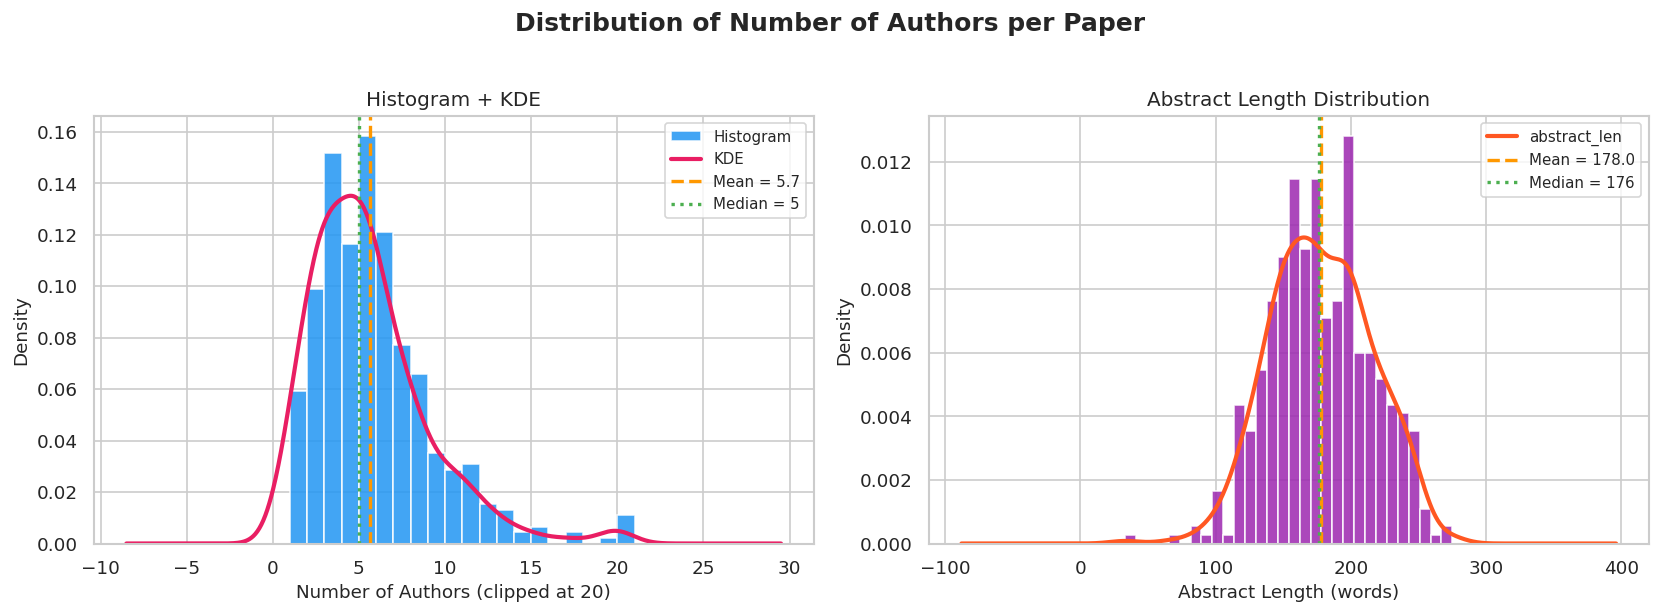

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Number of Authors per Paper', fontsize=15, fontweight='bold', y=1.02)

# left: histogram with KDE
ax = axes[0]
data = df['num_authors'].clip(upper=20)  # clip outliers for readability
ax.hist(data, bins=range(1, 22), color='#2196F3', edgecolor='white', alpha=0.85, density=True, label='Histogram')
data.plot.kde(ax=ax, color='#E91E63', linewidth=2.5, label='KDE')
ax.axvline(df['num_authors'].mean(), color='#FF9800', linewidth=2, linestyle='--',
           label=f"Mean = {df['num_authors'].mean():.1f}")
ax.axvline(df['num_authors'].median(), color='#4CAF50', linewidth=2, linestyle=':',
           label=f"Median = {df['num_authors'].median():.0f}")
ax.set_xlabel('Number of Authors (clipped at 20)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Histogram + KDE', fontsize=12)
ax.legend(fontsize=9)

# right: histogram of abstract length
ax2 = axes[1]
ax2.hist(df['abstract_len'], bins=30, color='#9C27B0', edgecolor='white', alpha=0.85, density=True)
df['abstract_len'].plot.kde(ax=ax2, color='#FF5722', linewidth=2.5)
ax2.axvline(df['abstract_len'].mean(), color='#FF9800', linewidth=2, linestyle='--',
            label=f"Mean = {df['abstract_len'].mean():.1f}")
ax2.axvline(df['abstract_len'].median(), color='#4CAF50', linewidth=2, linestyle=':',
            label=f"Median = {df['abstract_len'].median():.0f}")
ax2.set_xlabel('Abstract Length (words)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('Abstract Length Distribution', fontsize=12)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('viz1_histograms.png', bbox_inches='tight', dpi=150)
plt.show()

### Visualization 2 — Box Plots: Abstract Length by Primary Category

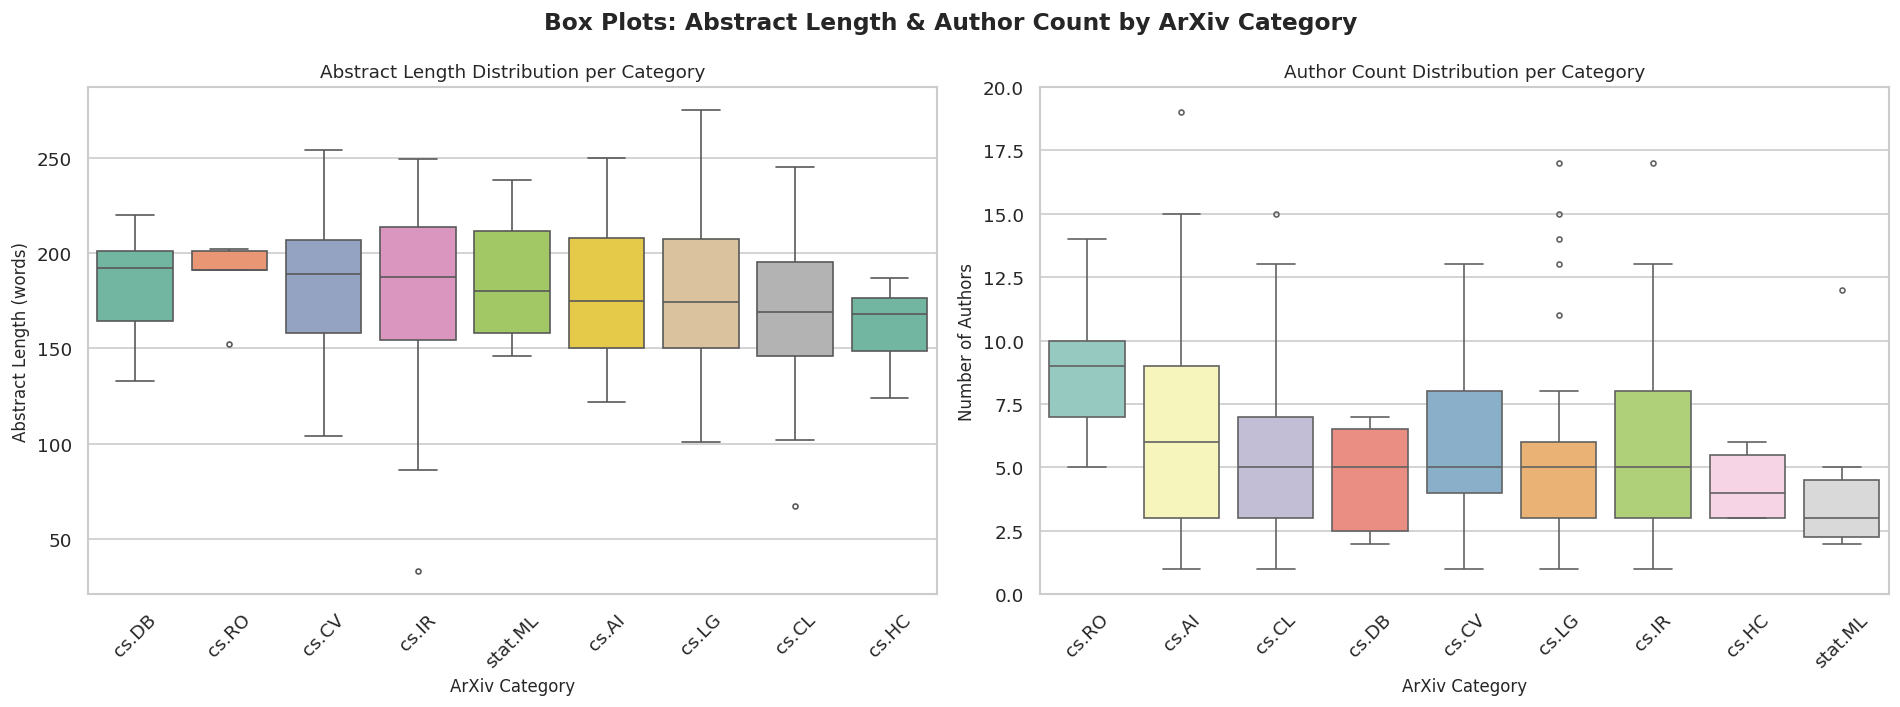

In [ ]:
# filter to categories with enough samples
cat_counts = df['primary_category'].value_counts()
valid_cats = cat_counts[cat_counts >= 5].index.tolist()[:12]  # top 12 categories
df_filtered = df[df['primary_category'].isin(valid_cats)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Box Plots: Abstract Length & Author Count by ArXiv Category',
             fontsize=14, fontweight='bold')

# left: abstract length by category
order = df_filtered.groupby('primary_category')['abstract_len'].median().sort_values(ascending=False).index
sns.boxplot(data=df_filtered, x='primary_category', y='abstract_len',
            order=order, palette='Set2', ax=axes[0], fliersize=3)
axes[0].set_xlabel('ArXiv Category', fontsize=10)
axes[0].set_ylabel('Abstract Length (words)', fontsize=10)
axes[0].set_title('Abstract Length Distribution per Category', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

# right: Num authors by category
order2 = df_filtered.groupby('primary_category')['num_authors'].median().sort_values(ascending=False).index
sns.boxplot(data=df_filtered, x='primary_category', y='num_authors',
            order=order2, palette='Set3', ax=axes[1], fliersize=3)
axes[1].set_ylim(0, 20)
axes[1].set_xlabel('ArXiv Category', fontsize=10)
axes[1].set_ylabel('Number of Authors', fontsize=10)
axes[1].set_title('Author Count Distribution per Category', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('viz2_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()

### Visualization 3 — Scatter Plot: Authors vs Abstract Length (colored by category)

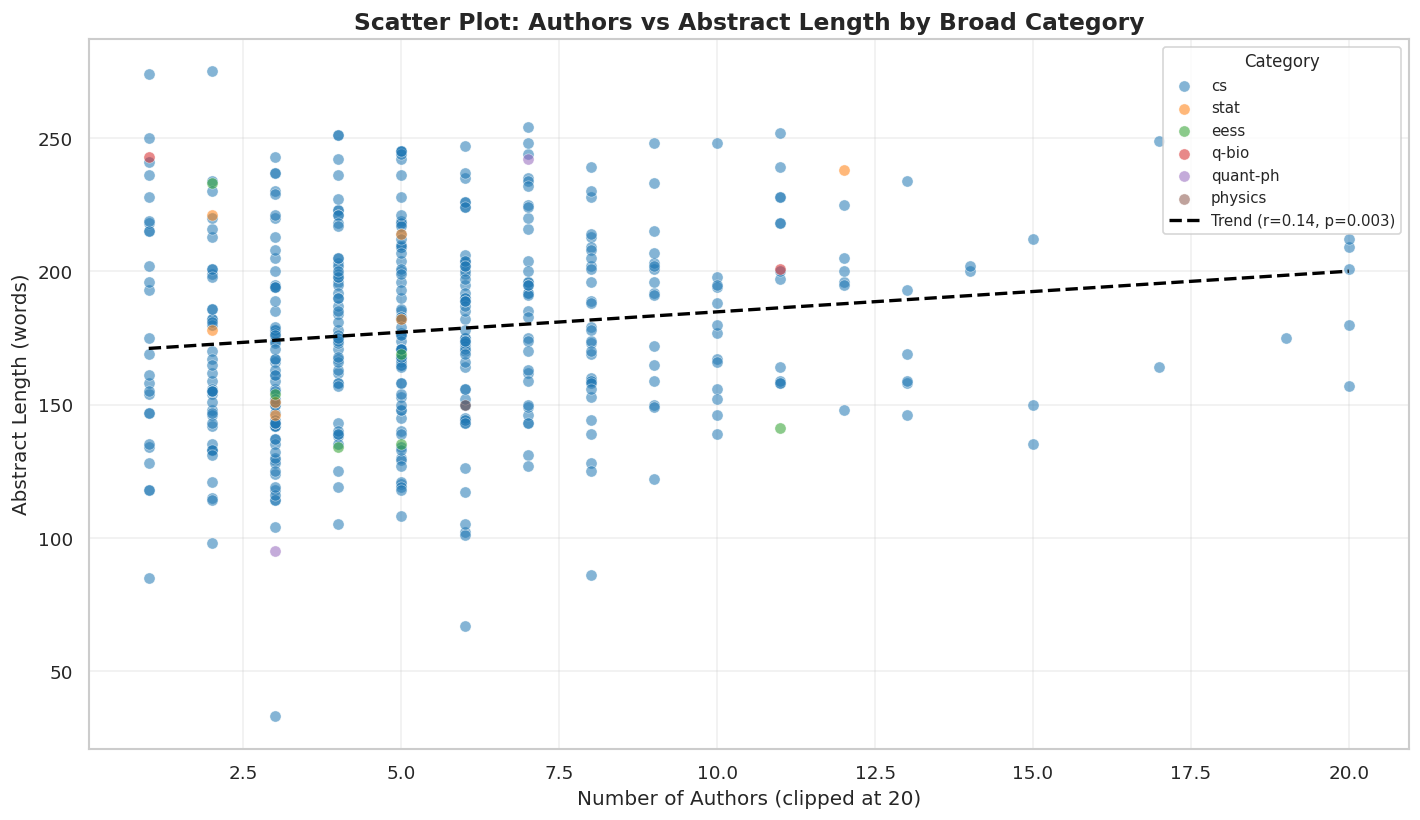

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

top_cats = df['primary_cat_clean'].value_counts().head(6).index
palette = sns.color_palette('tab10', len(top_cats))
cat_color = {cat: palette[i] for i, cat in enumerate(top_cats)}

for cat in top_cats:
    sub = df[df['primary_cat_clean'] == cat]
    ax.scatter(
        sub['num_authors'].clip(upper=20),
        sub['abstract_len'],
        color=cat_color[cat],
        alpha=0.55,
        s=45,
        label=cat,
        edgecolors='white',
        linewidths=0.4
    )

# regression line
x = df['num_authors'].clip(upper=20)
y = df['abstract_len']
slope, intercept, r, p, se = stats.linregress(x, y)
x_line = np.linspace(1, 20, 100)
ax.plot(x_line, slope * x_line + intercept, color='black', linewidth=2,
        linestyle='--', label=f'Trend (r={r:.2f}, p={p:.3f})')

ax.set_xlabel('Number of Authors (clipped at 20)', fontsize=12)
ax.set_ylabel('Abstract Length (words)', fontsize=12)
ax.set_title('Scatter Plot: Authors vs Abstract Length by Broad Category', fontsize=14, fontweight='bold')
ax.legend(title='Category', fontsize=9, title_fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('viz3_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

### Visualization 4 — Heatmap: Feature Correlation Matrix

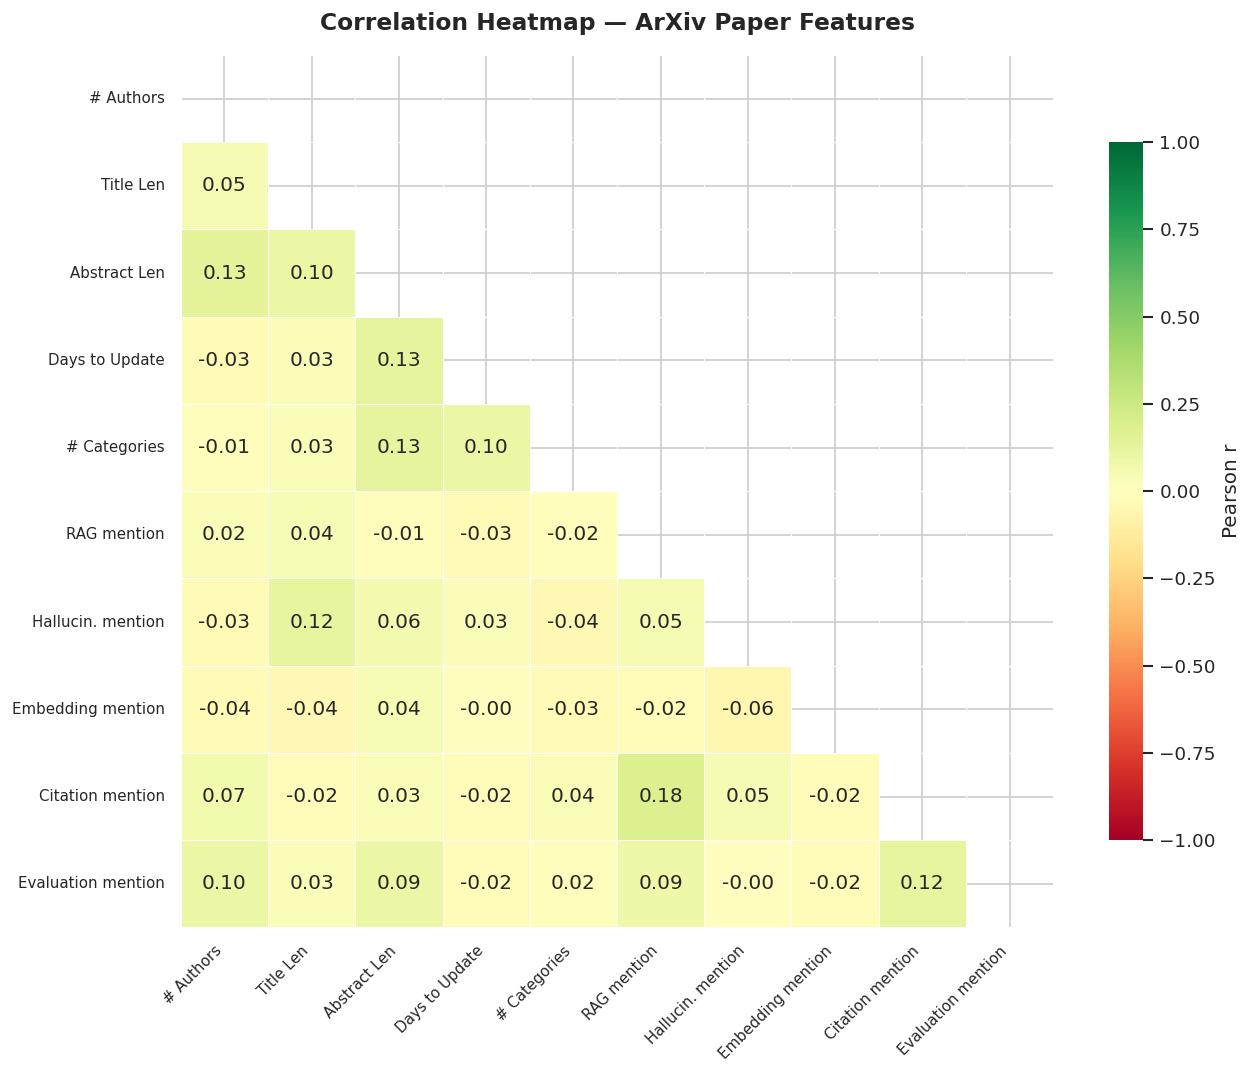

In [ ]:
corr_cols = ['num_authors', 'title_len', 'abstract_len', 'days_to_update',
             'num_categories', 'mentions_RAG', 'mentions_hallucin',
             'mentions_embedding', 'mentions_citation', 'mentions_evaluation']

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)

ax.set_title('Correlation Heatmap — ArXiv Paper Features', fontsize=14, fontweight='bold', pad=15)
labels = ['# Authors','Title Len','Abstract Len','Days to Update',
          '# Categories','RAG mention','Hallucin. mention',
          'Embedding mention','Citation mention','Evaluation mention']
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('viz4_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

### Visualization 5 — Word Cloud: Most Frequent Abstract Terms

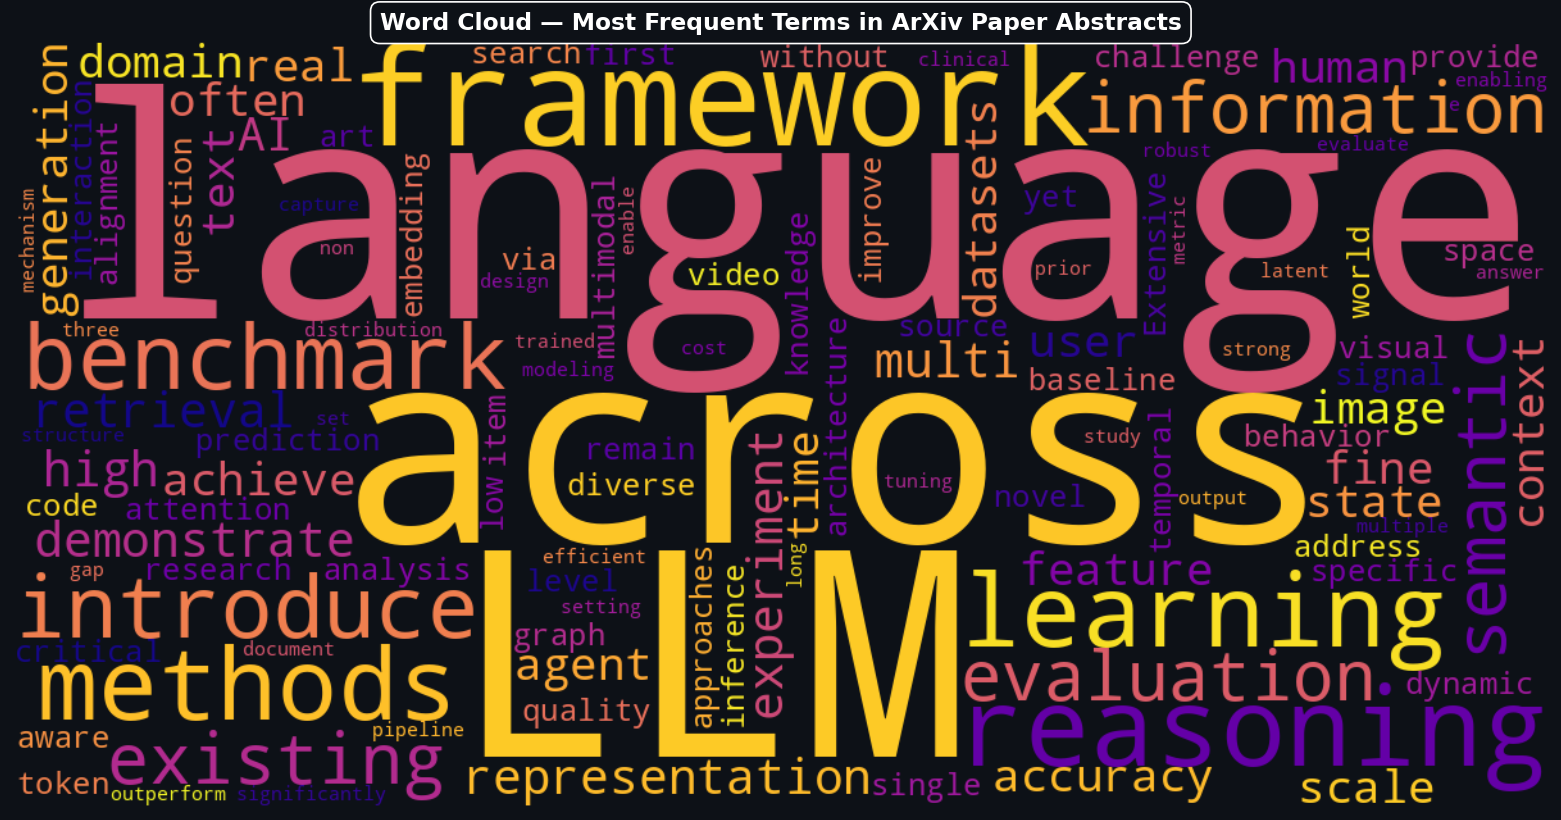

In [ ]:
from wordcloud import WordCloud, STOPWORDS

EXTRA_STOPS = {'paper','proposed','approach','method','model','models','using',
               'based','show','results','tasks','task','also','two','one',
               'systems','system','propose','present','new','large','work',
               'dataset','data','training','test','use','used','performance',
               'different','used','can','may','et','al','use'}
all_stops = STOPWORDS.union(EXTRA_STOPS)

all_text = ' '.join(df['abstract'].tolist())

wc = WordCloud(
    width=1200, height=600,
    background_color='#0D1117',
    colormap='plasma',
    stopwords=all_stops,
    max_words=120,
    collocations=False,
    min_font_size=9
).generate(all_text)

fig, ax = plt.subplots(figsize=(15, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud — Most Frequent Terms in ArXiv Paper Abstracts',
             fontsize=14, fontweight='bold', color='white',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#0D1117'))
fig.patch.set_facecolor('#0D1117')

plt.tight_layout()
plt.savefig('viz5_wordcloud.png', bbox_inches='tight', dpi=150, facecolor='#0D1117')
plt.show()

---
## 6. Export Dataset

In [ ]:
# save to CSV for downstream use in the project pipeline
export_cols = ['arxiv_id','title','abstract','authors','num_authors',
               'primary_category','primary_cat_clean','categories',
               'published','pub_year','pub_month','title_len','abstract_len',
               'days_to_update','num_categories','query_topic','query_category',
               'mentions_RAG','mentions_hallucin','mentions_embedding',
               'mentions_citation','mentions_transformer','mentions_evaluation']

df[export_cols].to_csv('arxiv_research_metadata.csv', index=False)
print(f'Exported arxiv_research_metadata.csv — {len(df)} rows × {len(export_cols)} columns')

# quick peek at final dataset
df[export_cols].head()

Exported arxiv_research_metadata.csv — 455 rows × 23 columns


,arxiv_id,title,abstract,authors,num_authors,primary_category,primary_cat_clean,categories,published,pub_year,...,days_to_update,num_categories,query_topic,query_category,mentions_RAG,mentions_hallucin,mentions_embedding,mentions_citation,mentions_transformer,mentions_evaluation
0,2602.23351v1,Scale Can't Overcome Pragmatics: The Impact of...,The lack of reasoning capabilities in Vision-L...,"[Amita Kamath, Jack Hessel, Khyathi Chandu, Je...",6,cs.CL,cs,"[cs.CL, cs.CV]",2026-02-26 18:54:06+00:00,2026,...,0,2,retrieval augmented generation,cs.CL,0,0,0,0,0,0
1,2602.23286v1,SPARTA: Scalable and Principled Benchmark of T...,Real-world Table-Text question answering (QA) ...,"[Sungho Park, Jueun Kim, Wook-Shin Han]",3,cs.CL,cs,"[cs.CL, cs.AI, cs.DB, cs.IR]",2026-02-26 17:59:51+00:00,2026,...,0,4,retrieval augmented generation,cs.CL,0,0,0,0,0,0
2,2602.23266v1,Discourse-Aware Dual-Track Streaming Response ...,Achieving human-like responsiveness is a criti...,"[Siyuan Liu, Jiahui Xu, Feng Jiang, Kuang Wang...",9,cs.CL,cs,[cs.CL],2026-02-26 17:39:56+00:00,2026,...,0,1,retrieval augmented generation,cs.CL,0,0,0,0,0,0
3,2602.23258v1,AgentDropoutV2: Optimizing Information Flow in...,While Multi-Agent Systems (MAS) excel in compl...,"[Yutong Wang, Siyuan Xiong, Xuebo Liu, Wenkang...",7,cs.AI,cs,"[cs.AI, cs.CL]",2026-02-26 17:31:43+00:00,2026,...,0,2,retrieval augmented generation,cs.CL,1,0,0,0,0,0
4,2602.23225v1,Why Diffusion Language Models Struggle with Tr...,Diffusion Language Models (DLMs) are often adv...,"[Pengxiang Li, Dilxat Muhtar, Lu Yin, Tianlong...",5,cs.CL,cs,"[cs.CL, cs.AI]",2026-02-26 17:04:57+00:00,2026,...,0,2,retrieval augmented generation,cs.CL,0,0,0,0,0,0


##7. Group Roles and Responsibilities
###1. Moulya Reddygari Bhupal: Setup & Data Collection

Primary Responsibility: Developing the infrastructure to interface with the ArXiv API for automated data retrieval.

Key Tasks: Writing scripts to query specific metadata fields (titles, abstracts, categories), managing API rate limits, and ensuring the raw dataset is successfully exported into a structured format like CSV.

###2. Sreyesh Varma Konduru: Data Cleaning & Feature Engineering

Primary Responsibility: Transforming raw, noisy text data into a refined format suitable for statistical analysis.

Key Tasks: Handling missing values, performing deduplication to remove redundant records, and creating new features through text processing techniques such as tokenization, stop-word removal, and vectorization.

###3. Karthikeya Myneedu: Descriptive Statistics

Primary Responsibility: Quantifying the core characteristics of the dataset through mathematical summaries.

Key Tasks: Calculating measures of central tendency (mean, median) and dispersion (variance, standard deviation) for publication trends, and performing frequency analysis on research categories to identify dominant themes.

###4. Anisha Gehlot: Visual Discovery

Primary Responsibility: Translating complex data patterns into intuitive, high-impact visual representations.

Key Tasks: Designing exploratory plots (histograms, scatter plots) for high-dimensional data visualization, and ensuring all charts are formatted for maximum clarity in the final report.